In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import ttest_ind, f_oneway, chi2_contingency

df = pd.read_csv('/content/StudentsPerformance.csv')

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

df.head()

Dataset Shape: (1000, 8)

Columns:
Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df['total_score'] = (
    df['math score'] +
    df['reading score'] +
    df['writing score']
)

df['average_score'] = df['total_score'] / 3

df.groupby('test preparation course')['average_score'].agg(
    ['count', 'mean', 'std']
)

,count,mean,std
test preparation course,,,
completed,358,72.669460,13.036960
none,642,65.038941,14.186707


In [4]:
completed = df[
    df['test preparation course'] == 'completed'
]['average_score']

none = df[
    df['test preparation course'] == 'none'
]['average_score']

t_stat, p_value = ttest_ind(
    completed,
    none,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 8.594538326688614
P-value: 4.426725271318694e-17


In [5]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant difference.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no statistically significant difference.")

Reject the null hypothesis.
There is a statistically significant difference.


In [6]:
mean1 = completed.mean()
mean2 = none.mean()

std1 = completed.std()
std2 = none.std()

n1 = len(completed)
n2 = len(none)

pooled_std = np.sqrt(
    ((n1 - 1) * std1**2 + (n2 - 1) * std2**2)
    / (n1 + n2 - 2)
)

cohens_d = (mean1 - mean2) / pooled_std

print("Cohen's d:", cohens_d)

Cohen's d: 0.553479854726847


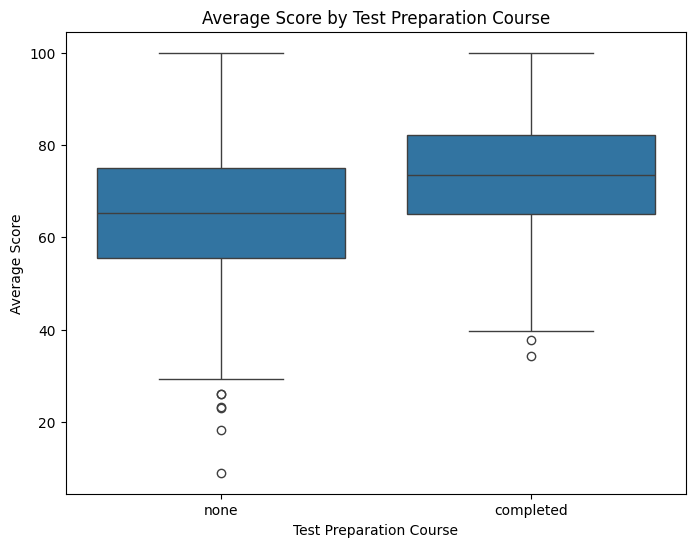

In [7]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x='test preparation course',
    y='average_score'
)

plt.title('Average Score by Test Preparation Course')
plt.xlabel('Test Preparation Course')
plt.ylabel('Average Score')

plt.show()

In [9]:
df['performance_category'] = pd.cut(
    df['average_score'],
    bins=[0, 50, 70, 100],
    labels=['Low', 'Medium', 'High']
)

contingency_table = pd.crosstab(
    df['lunch'],
    df['performance_category']
)

print(contingency_table)

performance_category  Low  Medium  High
lunch                                  
free/reduced           64     187   104
standard               45     257   343


In [10]:
chi2, p_value_chi, dof, expected = chi2_contingency(
    contingency_table
)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("P-value:", p_value_chi)

Chi-square statistic: 63.364378946757085
Degrees of freedom: 2
P-value: 1.7402030964942902e-14


One-Way ANOVA Test
-------------------
F-statistic: 10.75314696233657
P-value: 4.3810464809431664e-10

Reject the null hypothesis.
There is a statistically significant difference in student performance
among different parental education groups.


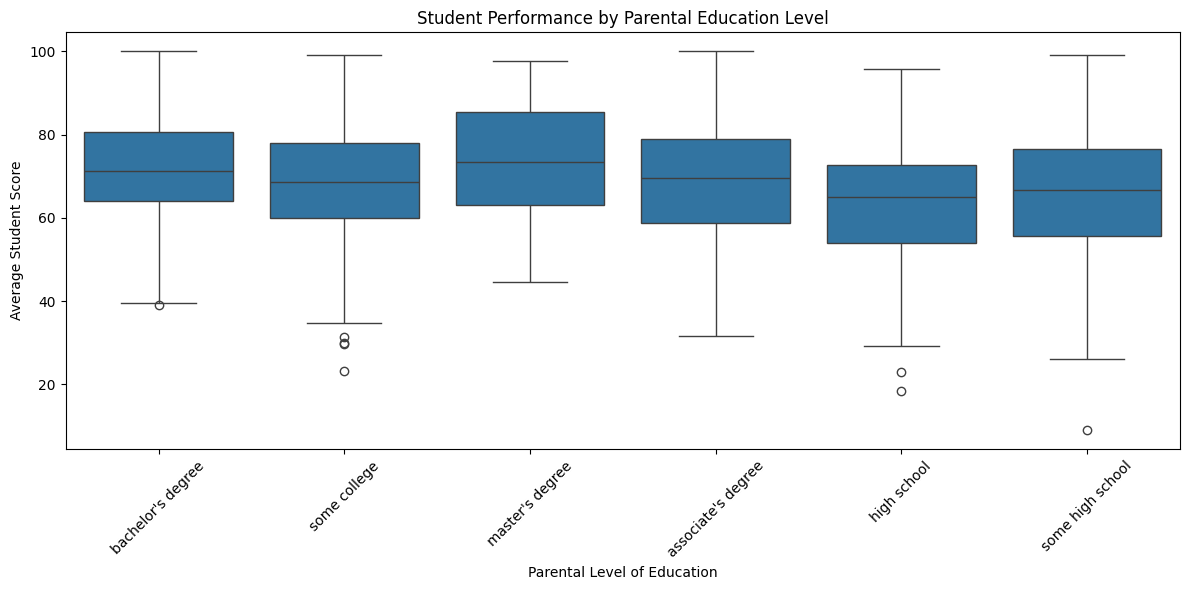

In [11]:
# 9. One-Way ANOVA: Average Score by Parental Education

import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Create average score
df['average_score'] = (
    df['math score'] +
    df['reading score'] +
    df['writing score']
) / 3

# Create groups based on parental education
groups = [
    group['average_score'].values
    for name, group in df.groupby('parental level of education')
]

# Perform ANOVA
f_statistic, p_value = stats.f_oneway(*groups)

print("One-Way ANOVA Test")
print("-------------------")
print("F-statistic:", f_statistic)
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("\nReject the null hypothesis.")
    print("There is a statistically significant difference in student performance")
    print("among different parental education groups.")
else:
    print("\nFail to reject the null hypothesis.")
    print("There is no statistically significant difference among the groups.")

# Visualization
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x='parental level of education',
    y='average_score'
)

plt.title("Student Performance by Parental Education Level")
plt.xlabel("Parental Level of Education")
plt.ylabel("Average Student Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
# 10. 95% Confidence Interval for Average Student Score

import scipy.stats as stats
import numpy as np

scores = df['average_score'].dropna()

mean_score = np.mean(scores)
std_error = stats.sem(scores)

confidence_level = 0.95

confidence_interval = stats.t.interval(
    confidence_level,
    len(scores) - 1,
    loc=mean_score,
    scale=std_error
)

print("Confidence Interval Analysis")
print("----------------------------")
print("Mean Average Score:", round(mean_score, 2))
print("95% Confidence Interval:")
print("Lower Bound:", round(confidence_interval[0], 2))
print("Upper Bound:", round(confidence_interval[1], 2))

Confidence Interval Analysis
----------------------------
Mean Average Score: 67.77
95% Confidence Interval:
Lower Bound: 66.89
Upper Bound: 68.66


In [13]:
# 11. Statistical Summary for Final Analysis

summary = df['average_score'].describe()

print("Statistical Summary of Student Performance")
print("------------------------------------------")
print("Number of Students :", int(summary['count']))
print("Mean               :", round(summary['mean'], 2))
print("Median             :", round(summary['50%'], 2))
print("Standard Deviation :", round(summary['std'], 2))
print("Minimum            :", round(summary['min'], 2))
print("Maximum            :", round(summary['max'], 2))

Statistical Summary of Student Performance
------------------------------------------
Number of Students : 1000
Mean               : 67.77
Median             : 68.33
Standard Deviation : 14.26
Minimum            : 9.0
Maximum            : 100.0


In [14]:
# 12. Overall Hypothesis Testing Summary

print("STATISTICAL HYPOTHESIS TESTING SUMMARY")
print("=" * 50)

print("\n1. T-TEST: Test Preparation Course")
print("T-statistic : 8.5945")
print("P-value     : 4.4267e-17")
print("Conclusion  : Statistically significant difference")

print("\n2. CHI-SQUARE TEST: Lunch vs Performance Category")
print("Chi-square  : 63.3644")
print("P-value     : 1.7402e-14")
print("Conclusion  : Statistically significant association")

print("\n3. ONE-WAY ANOVA: Parental Education")
print("F-statistic : 10.7531")
print("P-value     : 4.3810e-10")
print("Conclusion  : Statistically significant difference")

print("\n4. EFFECT SIZE: Cohen's d")
print("Cohen's d   : 0.5535")
print("Interpretation: Medium effect size")

print("\n5. CONFIDENCE INTERVAL")
print("Mean Score  : 67.77")
print("95% CI      : 66.89 - 68.66")

print("\nOverall Conclusion:")
print("The statistical analyses provide strong evidence that")
print("student performance is associated with several factors,")
print("including test preparation, lunch type, and parental education.")

STATISTICAL HYPOTHESIS TESTING SUMMARY

1. T-TEST: Test Preparation Course
T-statistic : 8.5945
P-value     : 4.4267e-17
Conclusion  : Statistically significant difference

2. CHI-SQUARE TEST: Lunch vs Performance Category
Chi-square  : 63.3644
P-value     : 1.7402e-14
Conclusion  : Statistically significant association

3. ONE-WAY ANOVA: Parental Education
F-statistic : 10.7531
P-value     : 4.3810e-10
Conclusion  : Statistically significant difference

4. EFFECT SIZE: Cohen's d
Cohen's d   : 0.5535
Interpretation: Medium effect size

5. CONFIDENCE INTERVAL
Mean Score  : 67.77
95% CI      : 66.89 - 68.66

Overall Conclusion:
The statistical analyses provide strong evidence that
student performance is associated with several factors,
including test preparation, lunch type, and parental education.


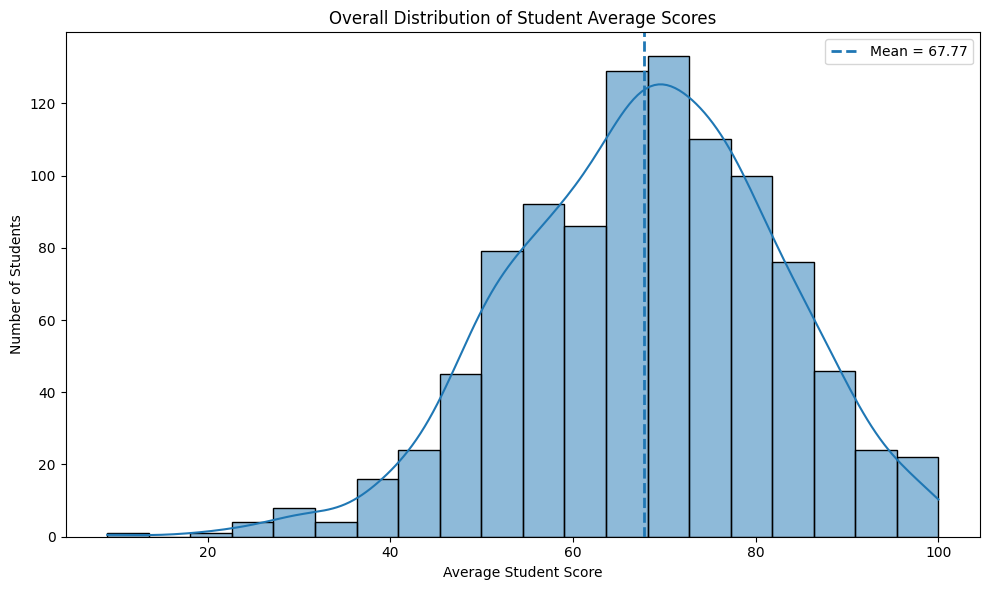

In [15]:
# 13. Overall Student Performance Distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    df['average_score'],
    bins=20,
    kde=True
)

plt.axvline(
    df['average_score'].mean(),
    linestyle='--',
    linewidth=2,
    label=f"Mean = {df['average_score'].mean():.2f}"
)

plt.title("Overall Distribution of Student Average Scores")
plt.xlabel("Average Student Score")
plt.ylabel("Number of Students")
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
# 14. Statistical Test Results Table

results = pd.DataFrame({
    'Statistical Test': [
        'Independent Samples T-Test',
        'Chi-Square Test',
        'One-Way ANOVA',
        "Cohen's d"
    ],
    'Test Statistic': [
        8.5945,
        63.3644,
        10.7531,
        0.5535
    ],
    'P-Value': [
        4.4267e-17,
        1.7402e-14,
        4.3810e-10,
        'N/A'
    ],
    'Interpretation': [
        'Significant',
        'Significant',
        'Significant',
        'Medium Effect'
    ]
})

results

,Statistical Test,Test Statistic,P-Value,Interpretation
0,Independent Samples T-Test,8.5945,0.0,Significant
1,Chi-Square Test,63.3644,0.0,Significant
2,One-Way ANOVA,10.7531,0.0,Significant
3,Cohen's d,0.5535,N/A,Medium Effect


Tukey HSD Post-Hoc Test
            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2      meandiff p-adj   lower    upper  reject
----------------------------------------------------------------------------
associate's degree bachelor's degree   2.3547 0.6743  -2.1739  6.8832  False
associate's degree       high school  -6.4721    0.0 -10.3682 -2.5761   True
associate's degree   master's degree   4.0298 0.3567  -1.7924   9.852  False
associate's degree      some college  -1.0927 0.9618  -4.8488  2.6635  False
associate's degree  some high school  -4.4611 0.0183  -8.4541  -0.468   True
 bachelor's degree       high school  -8.8268    0.0 -13.4584 -4.1952   True
 bachelor's degree   master's degree   1.6751 0.9748  -4.6629  8.0132  False
 bachelor's degree      some college  -3.4473 0.2479   -7.962  1.0673  False
 bachelor's degree  some high school  -6.8157 0.0006 -11.5293 -2.1022   True
       high school   master's degree  10.5019    0.0

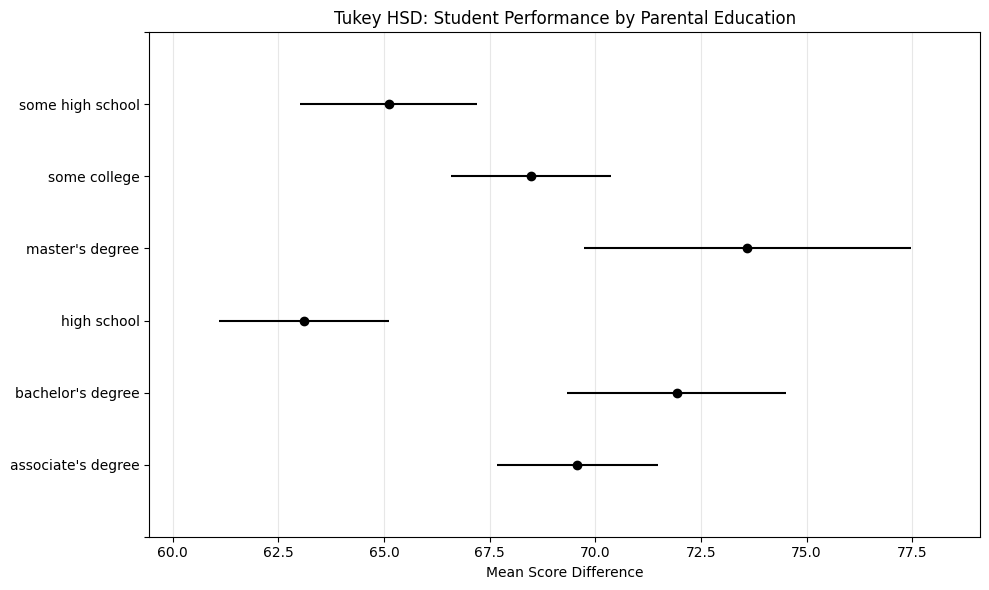

In [17]:
# 15. Tukey HSD Post-Hoc Test
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

# Tukey HSD test
tukey_result = pairwise_tukeyhsd(
    endog=df['average_score'],
    groups=df['parental level of education'],
    alpha=0.05
)

print("Tukey HSD Post-Hoc Test")
print("=" * 60)
print(tukey_result)

# Plot Tukey results
tukey_result.plot_simultaneous(figsize=(10, 6))
plt.title("Tukey HSD: Student Performance by Parental Education")
plt.xlabel("Mean Score Difference")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# 16. Practical Significance Analysis

completed_mean = df[df['test preparation course'] == 'completed']['average_score'].mean()
none_mean = df[df['test preparation course'] == 'none']['average_score'].mean()

mean_difference = completed_mean - none_mean
percentage_improvement = (mean_difference / none_mean) * 100

print("PRACTICAL SIGNIFICANCE ANALYSIS")
print("=" * 55)

print(f"Completed Test Preparation Mean : {completed_mean:.2f}")
print(f"No Test Preparation Mean        : {none_mean:.2f}")
print(f"Mean Score Difference            : {mean_difference:.2f}")
print(f"Percentage Improvement           : {percentage_improvement:.2f}%")

if percentage_improvement >= 10:
    interpretation = "Strong practical improvement"
elif percentage_improvement >= 5:
    interpretation = "Moderate practical improvement"
else:
    interpretation = "Small practical improvement"

print(f"Practical Interpretation         : {interpretation}")

PRACTICAL SIGNIFICANCE ANALYSIS
Completed Test Preparation Mean : 72.67
No Test Preparation Mean        : 65.04
Mean Score Difference            : 7.63
Percentage Improvement           : 11.73%
Practical Interpretation         : Strong practical improvement


LINEAR REGRESSION ANALYSIS
Slope              : 0.7872
Intercept           : 17.1418
R-squared           : 0.6684
P-value             : 1.7878e-241
Correlation (r)     : 0.8176
Conclusion          : Significant linear relationship


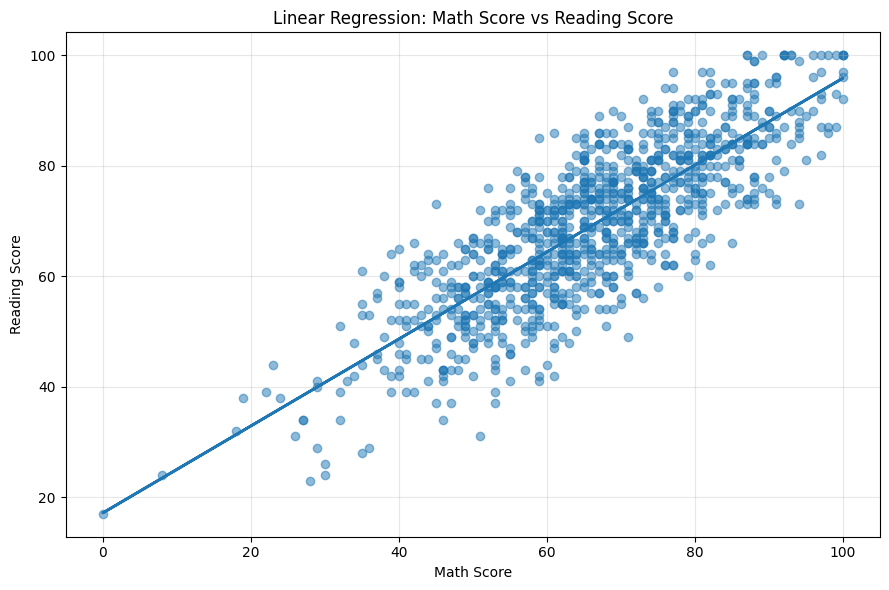

In [19]:
# 17. Linear Regression Analysis

from scipy.stats import linregress
import matplotlib.pyplot as plt

x = df['math score']
y = df['reading score']

slope, intercept, r_value, p_value, std_err = linregress(x, y)

print("LINEAR REGRESSION ANALYSIS")
print("=" * 55)
print(f"Slope              : {slope:.4f}")
print(f"Intercept           : {intercept:.4f}")
print(f"R-squared           : {r_value**2:.4f}")
print(f"P-value             : {p_value:.4e}")
print(f"Correlation (r)     : {r_value:.4f}")

if p_value < 0.05:
    print("Conclusion          : Significant linear relationship")
else:
    print("Conclusion          : No significant linear relationship")

# Regression line
plt.figure(figsize=(9, 6))
plt.scatter(x, y, alpha=0.5)
plt.plot(x, intercept + slope*x, linewidth=2)

plt.title("Linear Regression: Math Score vs Reading Score")
plt.xlabel("Math Score")
plt.ylabel("Reading Score")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
from scipy.stats import levene

# Test Preparation Course - Variance Test
completed_scores = df[df['test preparation course'] == 'completed']['average_score']
none_scores = df[df['test preparation course'] == 'none']['average_score']

stat, p = levene(completed_scores, none_scores)

print("LEVENE'S TEST FOR EQUALITY OF VARIANCES")
print("=" * 50)
print(f"Levene Statistic : {stat:.4f}")
print(f"P-value          : {p:.6f}")

if p > 0.05:
    print("Conclusion: Variances are statistically similar.")
    print("The equal-variance assumption is satisfied.")
else:
    print("Conclusion: Variances are significantly different.")
    print("The equal-variance assumption is not satisfied.")

LEVENE'S TEST FOR EQUALITY OF VARIANCES
Levene Statistic : 2.8851
P-value          : 0.089712
Conclusion: Variances are statistically similar.
The equal-variance assumption is satisfied.


NORMALITY TESTING - STUDENT PERFORMANCE

Descriptive Statistics
-----------------------------------
Number of Students : 1000
Mean Score         : 67.77
Median Score       : 68.33
Standard Deviation : 14.26

1. SHAPIRO-WILK TEST
-----------------------------------
Test Statistic : 0.993151
P-value        : 0.000145341
Conclusion: Reject the null hypothesis.
The scores significantly deviate from normality.

2. D'AGOSTINO'S K-SQUARED TEST
-----------------------------------
Test Statistic : 15.186721
P-value        : 0.000503785
Conclusion: Reject the null hypothesis.
The score distribution is not normal.


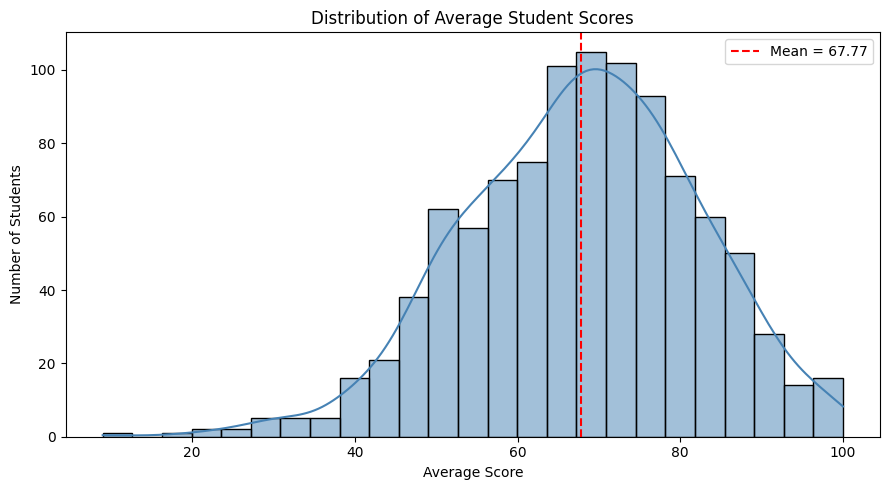

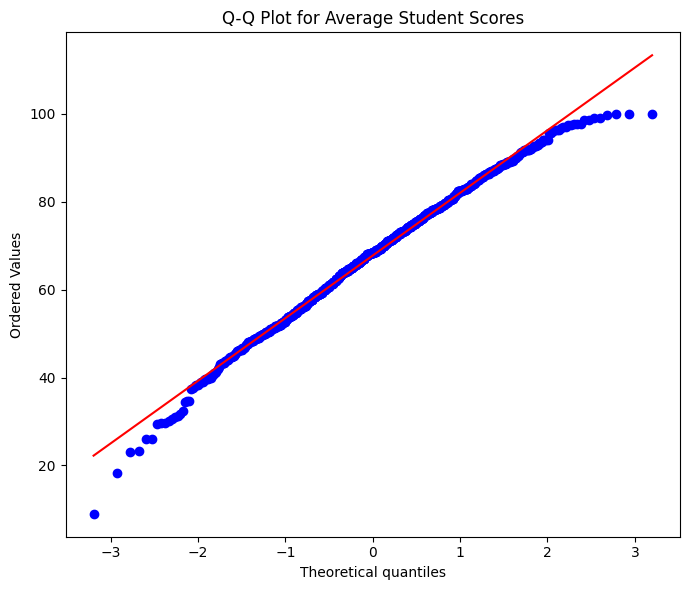


NORMALITY ANALYSIS COMPLETED


In [21]:
# ================================================
# WEEK 3: NORMALITY TESTING
# Student Performance Analysis
# ================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro, normaltest, probplot

# Create average score if not already available
if 'average_score' not in df.columns:
    df['average_score'] = df[
        ['math score', 'reading score', 'writing score']
    ].mean(axis=1)

scores = df['average_score'].dropna()

# --------------------------------
# 1. Descriptive Statistics
# --------------------------------

print("=" * 55)
print("NORMALITY TESTING - STUDENT PERFORMANCE")
print("=" * 55)

print("\nDescriptive Statistics")
print("-" * 35)
print(f"Number of Students : {len(scores)}")
print(f"Mean Score         : {scores.mean():.2f}")
print(f"Median Score       : {scores.median():.2f}")
print(f"Standard Deviation : {scores.std():.2f}")

# --------------------------------
# 2. Shapiro-Wilk Test
# --------------------------------

shapiro_stat, shapiro_p = shapiro(scores)

print("\n1. SHAPIRO-WILK TEST")
print("-" * 35)
print(f"Test Statistic : {shapiro_stat:.6f}")
print(f"P-value        : {shapiro_p:.6g}")

if shapiro_p < 0.05:
    print("Conclusion: Reject the null hypothesis.")
    print("The scores significantly deviate from normality.")
else:
    print("Conclusion: Fail to reject the null hypothesis.")
    print("No significant deviation from normality was detected.")

# --------------------------------
# 3. D'Agostino's K-squared Test
# --------------------------------

dag_stat, dag_p = normaltest(scores)

print("\n2. D'AGOSTINO'S K-SQUARED TEST")
print("-" * 35)
print(f"Test Statistic : {dag_stat:.6f}")
print(f"P-value        : {dag_p:.6g}")

if dag_p < 0.05:
    print("Conclusion: Reject the null hypothesis.")
    print("The score distribution is not normal.")
else:
    print("Conclusion: Fail to reject the null hypothesis.")
    print("The distribution is consistent with normality.")

# --------------------------------
# 4. Histogram with KDE
# --------------------------------

plt.figure(figsize=(9, 5))

sns.histplot(
    scores,
    bins=25,
    kde=True,
    color='steelblue',
    edgecolor='black'
)

plt.axvline(
    scores.mean(),
    color='red',
    linestyle='--',
    label=f'Mean = {scores.mean():.2f}'
)

plt.title('Distribution of Average Student Scores')
plt.xlabel('Average Score')
plt.ylabel('Number of Students')
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------------
# 5. Q-Q Plot
# --------------------------------

plt.figure(figsize=(7, 6))

probplot(scores, dist='norm', plot=plt)

plt.title('Q-Q Plot for Average Student Scores')
plt.tight_layout()
plt.show()

print("\nNORMALITY ANALYSIS COMPLETED")